# BinWaves example in Cantabria (Validation)

**In this notebook**: 
<br><br>
Here waves are reconstructed at the buoy location for comparison.
<br><br>
Steps:
- Buoy is loaded.
- Kp propagation coefficients and hindcast reconstruction is made at the buoy location.
- Comparison plots and statistics are shown.

In [9]:
import pandas as pd
import xarray as xr
import numpy as np

# Define buoy locations dictionary with both UTM and WGS84 coordinates
buoy_locations_dict = {
    '44088': {
        'utm': [514397.61, 4051843.74],  # UTM coordinates
        'wgs84': [36.6120, -74.8390]     # WGS84 coordinates (lat, lon)
    },
    '44100': {
        'utm': [446728.66, 4012728.08],  # UTM coordinates
        'wgs84': [36.2580, -75.5930]     # WGS84 coordinates (lat, lon)
    },
    '44086': {
        'utm': [462056.64, 3984141.31],  # UTM coordinates
        'wgs84': [36.0010, -75.4210]     # WGS84 coordinates (lat, lon)
    },
    '44056': {
        'utm': [435811.25, 4006367.97],  # UTM coordinates
        'wgs84': [36.2000, -75.7140]     # WGS84 coordinates (lat, lon)
    },
    '44095': {
        'utm': [470164.24, 3956270.58],  # UTM coordinates
        'wgs84': [35.7500, -75.3300]     # WGS84 coordinates (lat, lon)
    },
    '41120': {
        'utm': [474075.136, 3901692.114], # UTM coordinates
        'wgs84': [35.2580, -75.2850]     # WGS84 coordinates (lat, lon)
    },
    '41025': {
        'utm': [458576.64, 3874246.18],  # UTM coordinates
        'wgs84': [35.0100, -75.4540]     # WGS84 coordinates (lat, lon)
    }
}

def find_site_index(kp_coeffs, target_x, target_y, tolerance=1.0):
    """
    Find the site index in kp_coeffs that matches the target coordinates.
    
    Parameters:
    -----------
    kp_coeffs : xarray.Dataset
        The kp coefficients dataset
    target_x : float
        Target UTM x coordinate
    target_y : float
        Target UTM y coordinate
    tolerance : float
        Tolerance for coordinate matching (in meters)
        
    Returns:
    --------
    int
        The site index that matches the coordinates
    """
    # Get all site coordinates
    site_x = kp_coeffs.utm_x.values
    site_y = kp_coeffs.utm_y.values
    
    # Calculate distances to all sites
    distances = np.sqrt((site_x - target_x)**2 + (site_y - target_y)**2)
    
    # Find the site with minimum distance
    site_index = np.argmin(distances)
    
    # Check if the closest site is within tolerance
    if distances[site_index] > tolerance:
        print(f"Warning: Closest site is {distances[site_index]:.2f} meters away")
    
    return site_index

def load_buoy_data(buoy_id, year=None):
    """
    Load buoy data and return both the wave data and location coordinates.
    
    Parameters:
    -----------
    buoy_id : str
        The buoy ID (e.g., '44100')
    year : str, optional
        The year to filter data for (default: None)
        
    Returns:
    --------
    tuple
        (buoy_waves, buoy_location, kp_coeffs)
    """
    # Load buoy data
    buoy_waves = pd.read_pickle(f"outputs/buoy_{buoy_id}_bulk_parameters.pkl").sort_index()
    if year:
        buoy_waves = buoy_waves.loc[year]
    buoy_waves = buoy_waves.dropna(subset=['Hs_Buoy', 'Tp_Buoy', 'Dir_Buoy'])
    
    # Get buoy location (both UTM and WGS84)
    buoy_location = buoy_locations_dict[buoy_id]
    
    # Load kp coefficients
    kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")
    
    # Find the correct site index
    site_index = find_site_index(kp_coeffs, buoy_location['utm'][0], buoy_location['utm'][1])
    
    # Select the correct site
    kp_coeffs = kp_coeffs.isel(site=[site_index])
    
    return buoy_waves, buoy_location, kp_coeffs

# def load_buoy_data(buoy_id, start_year=None, end_year=None):
#     """
#     Load buoy data and return both the wave data and location coordinates.
    
#     Parameters:
#     -----------
#     buoy_id : str
#         The buoy ID (e.g., '44100')
#     start_year : str, optional
#         The start year to filter data from (default: None)
#     end_year : str, optional
#         The end year to filter data until (default: None). If not provided, uses all available data up to present.
        
#     Returns:
#     --------
#     tuple
#         (buoy_waves, buoy_location, kp_coeffs)
#     """
#     # Load buoy data
#     buoy_waves = pd.read_pickle(f"outputs/buoy_{buoy_id}_bulk_parameters.pkl").sort_index()
    
#     # Filter by year range if specified
#     if start_year:
#         if end_year:
#             buoy_waves = buoy_waves.loc[start_year:end_year]
#         else:
#             buoy_waves = buoy_waves.loc[start_year:]
            
#     buoy_waves = buoy_waves.dropna(subset=['Hs_Buoy', 'Tp_Buoy', 'Dir_Buoy'])
    
#     # Get buoy location (both UTM and WGS84)
#     buoy_location = buoy_locations_dict[buoy_id]
    
#     # Load kp coefficients
#     kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")
    
#     # Find the correct site index
#     site_index = find_site_index(kp_coeffs, buoy_location['utm'][0], buoy_location['utm'][1])
    
#     # Select the correct site
#     kp_coeffs = kp_coeffs.isel(site=[site_index])
    
#     return buoy_waves, buoy_location, kp_coeffs

# Example usage:
buoy_id = "41025"  # Change this to use different buoys
buoy_waves, buoy_location, kp_coeffs = load_buoy_data(buoy_id)

# Print the coordinates for verification
print(f"Buoy {buoy_id} coordinates:")
print(f"UTM: {buoy_location['utm']}")
print(f"WGS84: {buoy_location['wgs84']}")
print(f"\nSelected kp_coeffs site coordinates:")
print(f"UTM: {kp_coeffs.utm_x.values}, {kp_coeffs.utm_y.values}")

Buoy 41025 coordinates:
UTM: [458576.64, 3874246.18]
WGS84: [35.01, -75.454]

Selected kp_coeffs site coordinates:
UTM: [458576.64], [3874246.18]


In [10]:
from utils.operations import transform_ERA5_spectrum
import numpy as np
model_parameters = pd.read_csv("Duke2_cases/swan_cases.csv").to_dict(orient="list")

# Load interest spectra
offshore_spectra, offshore_spectra_case = (  # Unpack both values from the tuple
    transform_ERA5_spectrum(
        era5_spectrum=xr.open_dataset("outputs/jen_north_carolina_spec_utm_unique.nc"),
        subset_parameters=model_parameters,
        available_case_num=kp_coeffs.case_num.values,
    )
)



offshore_spectra_case.coords['longitude'] = np.float32(buoy_location['wgs84'][1]+360)
offshore_spectra_case.coords['latitude'] = np.float32(buoy_location['wgs84'][0])

# Add attributes to the coordinates
offshore_spectra_case.coords['longitude'].attrs = {
    'units': 'degrees_east',
    'long_name': 'Longitude'
}
offshore_spectra_case.coords['latitude'].attrs = {
    'units': 'degrees_north',
    'long_name': 'Latitude'
}
offshore_spectra_case

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/core/accessor_dt.py:163: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  field_values = method(freq=freq).values


<xarray.DataArray 'efth' (case_num: 695, time: 405409)> Size: 1GB
array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 7.0847166e-20,
        7.2790246e-20, 6.9479947e-20],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0095968e-19,
        1.0773933e-19, 1.1075864e-19],
       ...,
       [0.0000000e+00, 3.8440106e-27, 2.4607124e-22, ..., 6.3432267e-12,
        6.6909811e-12, 5.5221825e-12],
       [0.0000000e+00, 2.4330966e-27, 1.5166782e-22, ..., 2.2817579e-12,
        2.6370165e-12, 2.0167759e-12],
       [0.0000000e+00, 4.5172463e-25, 8.0684214e-23, ..., 1.0713248e-12,
        1.1941346e-12, 7.9873337e-13]], shape=(695, 405409), dtype=float32)
Coordinates:
  * case_num   (case_num) int64 6kB 0 1 2 3 4 5 6 ... 690 691 692 693 694 695
    station    int32 4B 133
  * time       (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01
    longitude  float32 4B 284.5
    latitude   float32 4B 35.01

In [11]:
# import xarray as xr

# # Load the dataset
# offshore_spectra_case = xr.open_dataset("outputs/jen_north_carolina_spec_utm_unique.nc")


# import numpy as np
# times = offshore_spectra_case.time.to_index()
# unique_times, unique_idx = np.unique(offshore_spectra_case.time.values, return_index=True)
# offshore_spectra_case = offshore_spectra_case.isel(time=unique_idx)
# offshore_spectra_case.to_netcdf("outputs/jen_north_carolina_spec_utm_unique.nc")

In [12]:
from bluemath_tk.waves.binwaves import reconstruc_spectra
# Reconstruct spectra

reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=buoy_waves.index, method="nearest"),
    kp_coeffs=kp_coeffs,
)
reconstructed_onshore_spectra

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36671 instead
  warnings.warn(
/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 236.52 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.Dataset> Size: 523MB
Dimensions:    (site: 1, freq: 31, dir: 24, time: 87833)
Coordinates:
  * site       (site) int64 8B 1672
  * freq       (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir        (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    lat        float64 8B 0.0
    lon        float64 8B 0.0
    utm_x      (site) float64 8B 4.586e+05
    utm_y      (site) float64 8B 3.874e+06
    station    int32 4B 133
  * time       (time) datetime64[ns] 703kB 2012-07-01T01:00:00 ... 2025-01-01
    longitude  float32 4B 284.5
    latitude   float32 4B 35.01
Data variables:
    kps        (time, site, freq, dir) float64 523MB 0.0 0.0 ... 4.358e-13

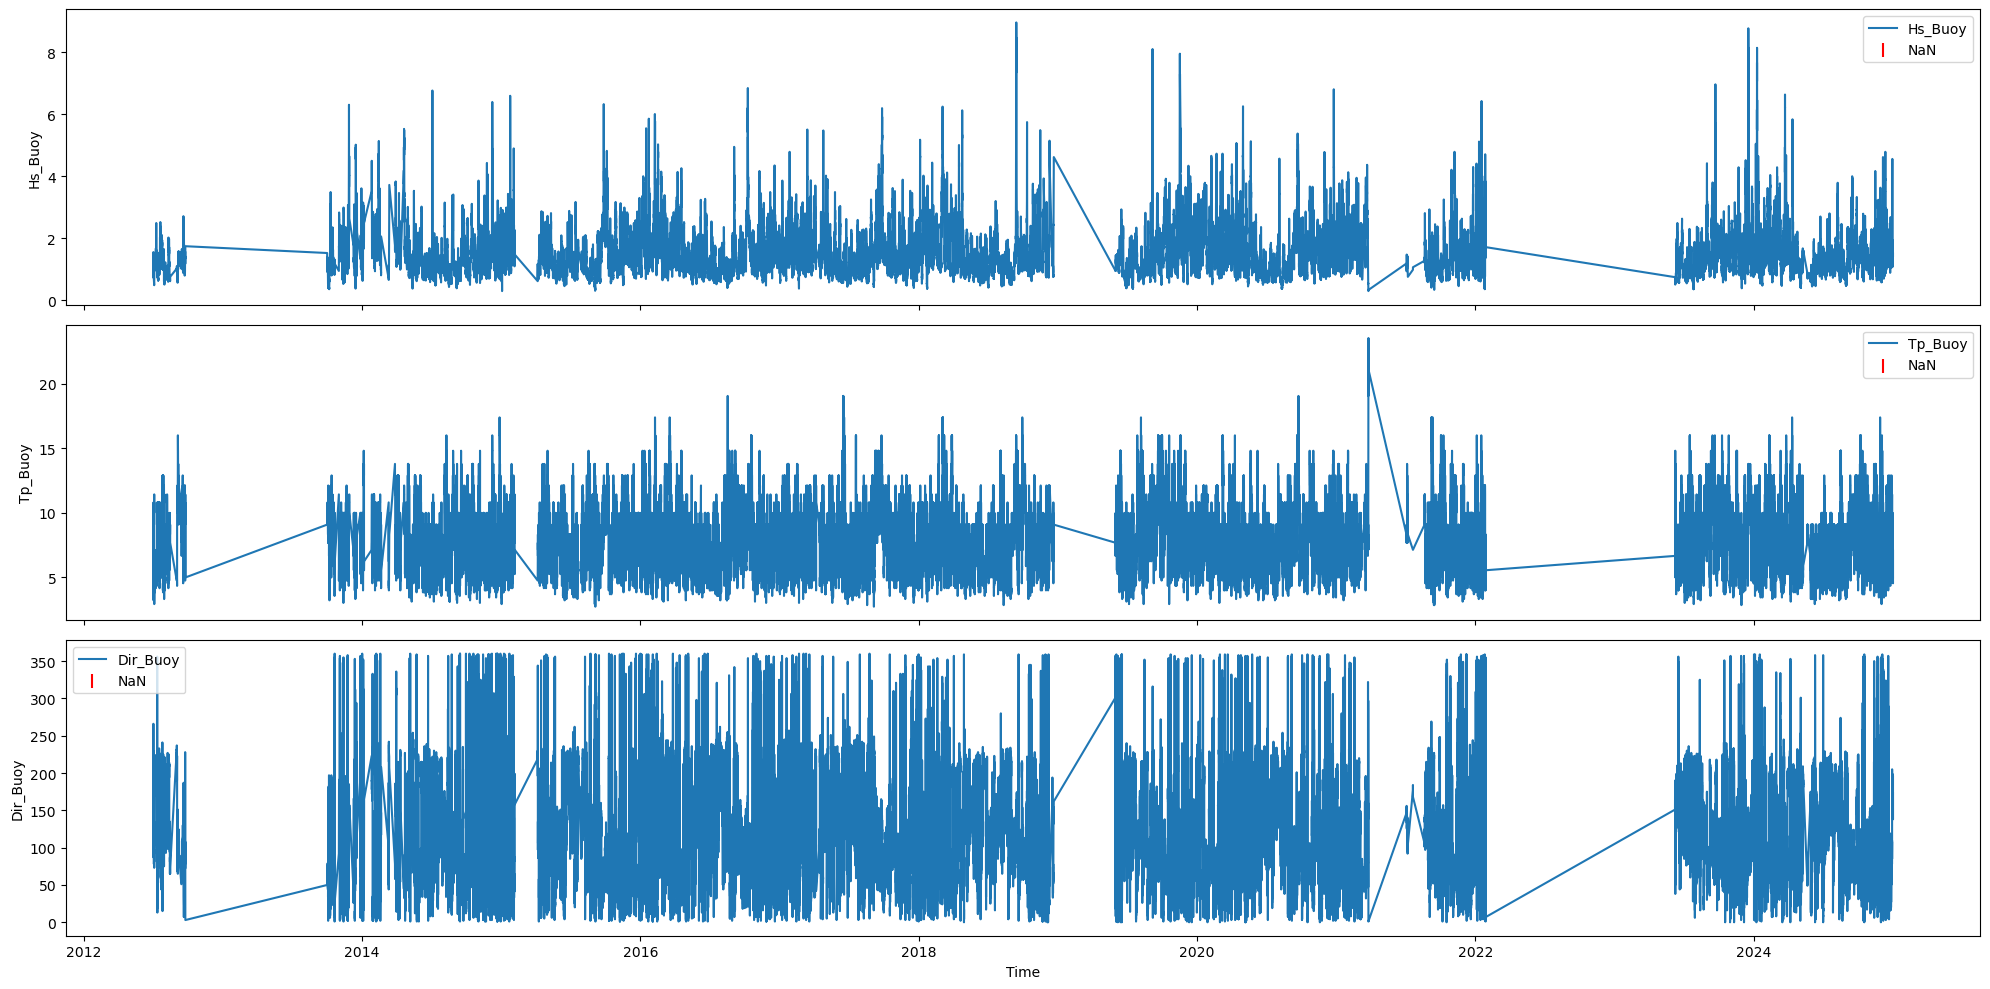

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

for i, var in enumerate(['Hs_Buoy', 'Tp_Buoy', 'Dir_Buoy']):
    axes[i].plot(buoy_waves.index, buoy_waves[var], label=var)
    # Overlay NaN locations
    nan_locs = buoy_waves[var].isna()
    axes[i].scatter(buoy_waves.index[nan_locs], [axes[i].get_ylim()[0]]*nan_locs.sum(), 
                    color='red', marker='|', s=100, label='NaN')
    axes[i].set_ylabel(var)
    axes[i].legend()

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)
/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


(<Figure size 2000x1000 with 3 Axes>,
 <Figure size 1500x500 with 3 Axes>,
 array([<Axes: xlabel='Hs - Buoy [m]', ylabel='Hs - BinWaves [m]'>,
        <Axes: xlabel='Tp - Buoy [s]', ylabel='Tp - BinWaves [s]'>,
        <Axes: xlabel='Dir - Buoy [°]', ylabel='Dir - BinWaves [°]'>],
       dtype=object))

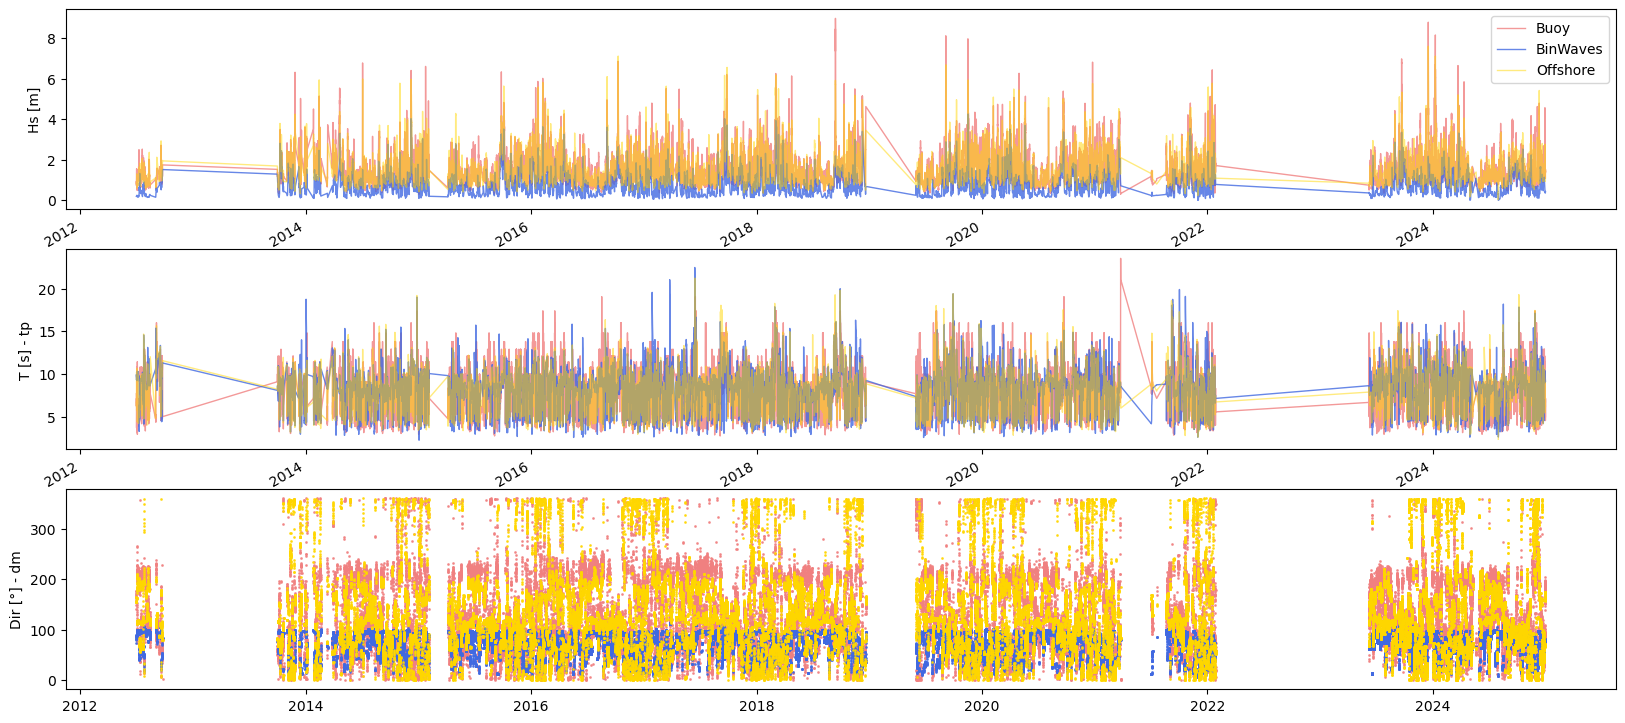

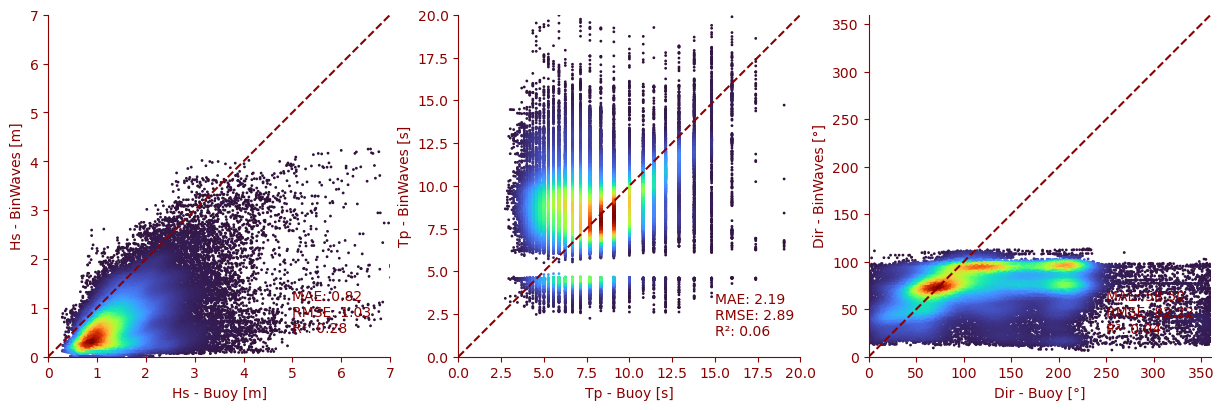

In [14]:
from utils.plotting import plot_wave_series



plot_wave_series(
    buoy_data=buoy_waves,
    binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
    .squeeze()
    .drop_duplicates('time')
    .sel(time=buoy_waves.index, method="nearest")
    .spec,
    offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
    times=buoy_waves.index.values,
    buoyId=buoy_id,
    save_dir='outputs/Figures/'  # Specify where to save the figures
)

In [15]:
from utils.data_export import save_wave_series_to_csv
save_wave_series_to_csv(
    buoy_data=buoy_waves,
    binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
        .squeeze()
        .drop_duplicates('time')  # Add this line to remove duplicates
        .sel(time=buoy_waves.index, method="nearest")
        .spec,
    times=buoy_waves.index.values,
    output_file=f'outputs/buoy_{buoy_id}_validation.csv'
)


Starting to save wave series data...
Created DataFrame with shape: (87833, 7)
Saving to: outputs/buoy_41025_validation.csv
Successfully saved original data
Creating 3-hourly version...
Saving 3-hourly data to: outputs/buoy_41025_validation_3h.csv


/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/utils/data_export.py:53: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_3h = df.resample('3H', on='date').mean()


Successfully saved 3-hourly data
